# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [2]:
import pandas as pd

df = pd.read_csv('/content/hotels.csv')
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1.  There were some missing values from agent and company columns, and in the case of adr, the first two rows showed 0.0 but rest of them were not.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create 'total_nights' feature
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Select features
selected_features = ['lead_time', 'adults', 'adr', 'total_of_special_requests', 'total_nights']
features_df = df[selected_features].copy()

# Drop missing values
# print(f"Shape before dropping NaNs: {features_df.shape}") # For debugging
features_df.dropna(inplace=True)
# print(f"Shape after dropping NaNs: {features_df.shape}") # For debugging

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# Convert the scaled array back to a DataFrame
scaled_features_df = pd.DataFrame(scaled_features, columns=features_df.columns)

print("Features prepared and standardized successfully. Displaying first 5 rows of scaled data:")
display(scaled_features_df.head())

Features prepared and standardized successfully. Displaying first 5 rows of scaled data:


,lead_time,adults,adr,total_of_special_requests,total_nights
0,2.227051,0.247897,-2.015038,-0.720694,-1.340370
1,5.923385,0.247897,-2.015038,-0.720694,-1.340370
2,-0.907814,-1.478447,-0.530935,-0.720694,-0.949352
3,-0.851667,-1.478447,-0.530935,-0.720694,-0.949352
4,-0.842309,0.247897,-0.075810,0.540666,-0.558334


### ✍️ Your Response: 🔧
1.I chose lead_time, adults, adr, total_of_special_requests, total_nights since these show the customer behaviors and features.
2. I expect that I can find the segments of different behavioral customers like lots of adults booked vs one or two adults, some special request vs no request.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



## Exploring K-Means with different `k` values

To understand the impact of choosing different `k` values, let's re-run K-Means with `k=3` and `k=5` and visualize the results.

K-Means clustering applied with k=4 clusters. Cluster labels added to DataFrame.


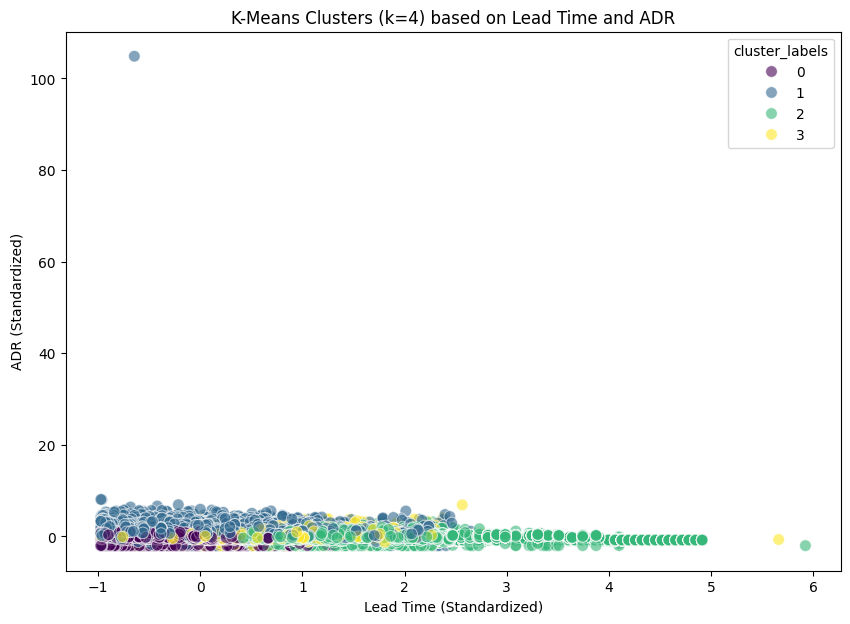

Scatterplot of clusters (k=4) displayed successfully.


In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

k = 4 # As specified in the task
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
scaled_features_df['cluster_labels'] = kmeans.fit_predict(scaled_features_df)

print(f"K-Means clustering applied with k={k} clusters. Cluster labels added to DataFrame.")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scaled_features_df,
    x='lead_time',
    y='adr',
    hue='cluster_labels',
    palette='viridis',
    legend='full',
    alpha=0.6,
    s=70 # Increased marker size for better visibility
)
plt.title(f'K-Means Clusters (k={k}) based on Lead Time and ADR')
plt.xlabel('Lead Time (Standardized)')
plt.ylabel('ADR (Standardized)')
plt.show()

print(f"Scatterplot of clusters (k={k}) displayed successfully.")

### ✍️ Your Response: 🔧
1. I chose k=4 since it is the middle number and have advantage to analyze.

2. The clusters show four customer types: spontaneous budget travelers, luxury planners, last-minute high spenders, and budget-conscious planners. These groups differ mainly in booking timing and room rate, suggesting meaningful variation in how far in advance customers book and how much they are willing to spend.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


Gaussian Mixture Model applied with k=4 components. GMM cluster labels and probabilities added to DataFrame.


,lead_time,adults,adr,total_of_special_requests,total_nights,cluster_labels,gmm_cluster_labels,gmm_cluster_probs
0,2.227051,0.247897,-2.015038,-0.720694,-1.340370,2,3,"[0.0, 4.509438807368342e-07, 0.214783603004602..."
1,5.923385,0.247897,-2.015038,-0.720694,-1.340370,2,3,"[0.0, 9.72180097699115e-14, 9.760097717387901e..."
2,-0.907814,-1.478447,-0.530935,-0.720694,-0.949352,0,0,"[0.9999997659728764, 2.3402712367029675e-07, 0..."
3,-0.851667,-1.478447,-0.530935,-0.720694,-0.949352,0,0,"[0.9999997583718677, 2.416281322969629e-07, 0...."
4,-0.842309,0.247897,-0.075810,0.540666,-0.558334,0,3,"[0.0, 7.650695266637431e-06, 0.0, 0.9999923493..."


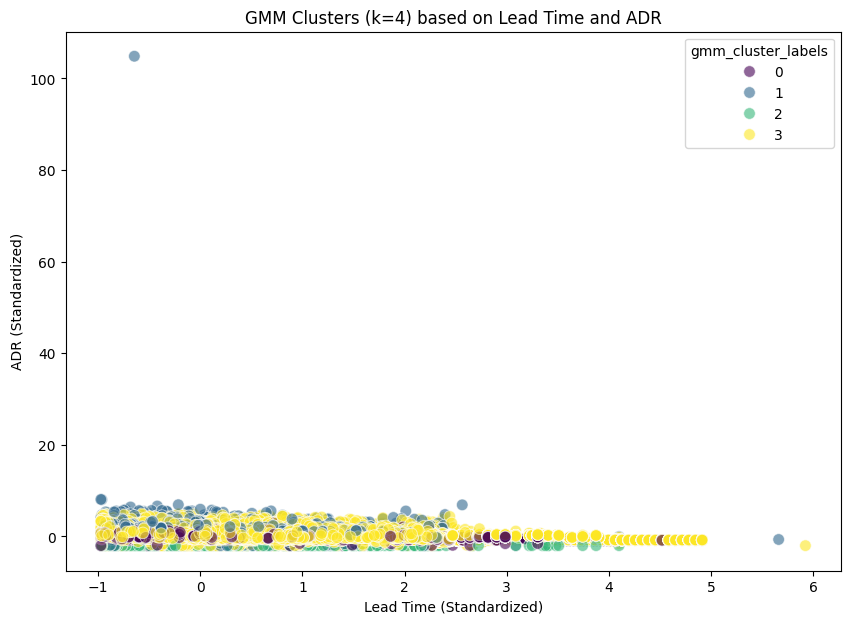

Scatterplot of GMM clusters (k=4) displayed successfully.


In [22]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

gmm = GaussianMixture(n_components=k, random_state=42)

# Define the features to be used for GMM, excluding all cluster-related columns
# We'll use the original `selected_features` list to ensure only numerical features are passed
X_for_gmm = scaled_features_df[selected_features].copy()

# Fit GMM on these features
gmm.fit(X_for_gmm)

# Predict hard clusters (most likely cluster assignment)
scaled_features_df['gmm_cluster_labels'] = gmm.predict(X_for_gmm)

# Predict soft clusters (probabilities of belonging to each cluster)
scaled_features_df['gmm_cluster_probs'] = list(gmm.predict_proba(X_for_gmm))

print(f"Gaussian Mixture Model applied with k={k} components. GMM cluster labels and probabilities added to DataFrame.")
display(scaled_features_df.head())

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scaled_features_df,
    x='lead_time',
    y='adr',
    hue='gmm_cluster_labels',
    palette='viridis',
    legend='full',
    alpha=0.6,
    s=70
)
plt.title(f'GMM Clusters (k={k}) based on Lead Time and ADR')
plt.xlabel('Lead Time (Standardized)')
plt.ylabel('ADR (Standardized)')
plt.show()

print(f"Scatterplot of GMM clusters (k={k}) displayed successfully.")

### ✍️ Your Response: 🔧
1. In my case, GMM had similar with the clustering one.

2.GMM is more flexible than clustering since it offer how many percentage the specific data will group in specific sections.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [24]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# --- Evaluation for K-Means ---
print("\n--- K-Means Model Evaluation (k=4) ---")

# WCSS (Inertia) - directly from the fitted model
kmeans_wcss = kmeans.inertia_
print(f"K-Means WCSS: {kmeans_wcss:.2f}")

# For Silhouette Score and Davies-Bouldin Index, use a sample if dataset is large
# It's computationally intensive, as noted in the assignment
num_samples = 10000
if len(scaled_features_df) > num_samples:
    sample_df = scaled_features_df.sample(n=num_samples, random_state=42)
    sample_features = sample_df[selected_features]
    sample_kmeans_labels = sample_df['cluster_labels']
    sample_gmm_labels = sample_df['gmm_cluster_labels'] # Also sample GMM labels for fairness
else:
    sample_features = scaled_features_df[selected_features]
    sample_kmeans_labels = scaled_features_df['cluster_labels']
    sample_gmm_labels = scaled_features_df['gmm_cluster_labels']

# Silhouette Score for K-Means
kmeans_silhouette = silhouette_score(sample_features, sample_kmeans_labels)
print(f"K-Means Silhouette Score (sample): {kmeans_silhouette:.4f}")

# Davies-Bouldin Index for K-Means
kmeans_davies_bouldin = davies_bouldin_score(sample_features, sample_kmeans_labels)
print(f"K-Means Davies-Bouldin Index (sample): {kmeans_davies_bouldin:.4f}")

# --- Evaluation for GMM ---
print("\n--- GMM Model Evaluation (k=4) ---")

# GMM doesn't have a direct 'inertia_' equivalent like K-Means.
# The closest is the negative log-likelihood of the data given the model, which is output by score() method.
# A higher score() value indicates a better fit (lower negative log-likelihood).
# For comparison, we will still compute Silhouette and Davies-Bouldin based on hard assignments.

# Silhouette Score for GMM (using hard assignments)
gmm_silhouette = silhouette_score(sample_features, sample_gmm_labels)
print(f"GMM Silhouette Score (sample): {gmm_silhouette:.4f}")

# Davies-Bouldin Index for GMM (using hard assignments)
gmm_davies_bouldin = davies_bouldin_score(sample_features, sample_gmm_labels)
print(f"GMM Davies-Bouldin Index (sample): {gmm_davies_bouldin:.4f}")

# Optionally, also display GMM's log-likelihood score for completeness
gmm_log_likelihood = gmm.score(sample_features)
print(f"GMM Average Log-Likelihood (score): {gmm_log_likelihood:.4f}")



--- K-Means Model Evaluation (k=4) ---
K-Means WCSS: 367636.00
K-Means Silhouette Score (sample): 0.2373
K-Means Davies-Bouldin Index (sample): 1.3905

--- GMM Model Evaluation (k=4) ---
GMM Silhouette Score (sample): 0.1850
GMM Davies-Bouldin Index (sample): 2.1680
GMM Average Log-Likelihood (score): -0.4819


### ✍️ Your Response: 🔧
1.K-means performed better than GMM

2. In this case, I would recommend K-means since it performed better than GMM to grouping and categorize.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [28]:
import pandas as pd

# Ensure `features_df` contains the unscaled values and `cluster_labels` are aligned.
# Since scaled_features_df was created from features_df after dropping NaNs, their indices should align.
# We can add the cluster_labels directly to features_df using its index.
features_with_clusters = features_df.copy()
features_with_clusters['cluster_labels'] = scaled_features_df['cluster_labels'].values

# Group by cluster_labels and calculate the mean for each feature
cluster_means = features_with_clusters.groupby('cluster_labels')[selected_features].mean()

print("Mean of features for each K-Means cluster (sorted by ADR):")
display(cluster_means.sort_values(by='adr', ascending=False))

Mean of features for each K-Means cluster (sorted by ADR):


,lead_time,adults,adr,total_of_special_requests,total_nights
cluster_labels,,,,,
1,72.376064,2.124429,141.879806,1.392967,3.268507
3,133.224479,1.940501,97.366336,0.542510,8.553156
2,275.464590,1.932380,88.557818,0.198391,2.984471
0,46.749271,1.638818,83.590516,0.222087,2.412406


### ✍️ Your Response: 🔧
1.0: low-budget, book the hotel late. (focus on price)
  1. High-budget, focus on high-quality service.
  2: Low budget, but book the hotel early, which mean they focus on affordable price.
  3. Long-term, but book early. (long-term customers)

2.for 0, I would recommend to offer instant discount coupon, and 1, offer high-quality service like concierge service, and room upgrade. For 2, offering discount by booking early (like in 2 days they made decisions) and for 3, laundry service and discount parking lot service would be good idea for them.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The hardest thing for me was comparing HMM and K-Means since they showed the similar result in scatterplot.

2.Clustering would be good for reducing variables by creating missing values and outlier. I will use it when there would be those values which will impact to misinterpret.

3. I will explain these by showing the data which have wrong informations, erasing it, and grouping and categorize them and clustering is the similar things, but by using the laptop.

4. In logistics departments, there would be lots of missing values like customer satisfactions since lots of people ignore it. I would use that in that situation and analyze, make the right decision.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"